> **Aviso de leitura.** A tabela produzida abaixo **não responde** à pergunta de pesquisa, embora tenha sido escrita como se respondesse. Ela compara os três algoritmos sobre um rótulo que é função determinística de duas de suas próprias variáveis de entrada; a diferença de onze pontos percentuais de F1-macro entre a floresta e os modelos de fronteira suave é artefato da codificação por valor-sentinela, e desaparece por completo quando a sentinela é substituída por um indicador explícito (`run_ablation.py`, configuração `sentinel_fixed`).

> A comparação válida está em `run_comparison.py`. Ver [`docs/discussao-limitacoes-contribuicoes.md`](../docs/discussao-limitacoes-contribuicoes.md), seções 3 e 4.


# Capítulo 4 — Avaliação: Métricas e Comparação entre Cenários
Calculamos as métricas de classificação para cada algoritmo em cada cenário,
exibimos matrizes de confusão e produzimos a tabela comparativa do primeiro experimento —
que, como o aviso acima registra, não é a que responde à pergunta de pesquisa.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from reconciliacao.utils.config import load_config
from reconciliacao.models.features import build_features
from reconciliacao.models.trainer import train_all
from reconciliacao.models.evaluator import evaluate_all

cfg = load_config("../config.yaml")
all_metrics = []

for scenario in ["exact", "fuzzy"]:
    df = pd.read_csv(f"../data/processed/{scenario}_reconciliado.csv")
    X, y = build_features(df)
    results = train_all(X, y, cfg, Path(f"../data/results/{scenario}/models"))
    scfg = cfg["scenarios"][scenario]
    metrics = evaluate_all(results, scfg["n_classes"], Path(f"../data/results/{scenario}"))
    metrics["scenario"] = scenario
    all_metrics.append(metrics.reset_index())

summary = pd.concat(all_metrics).set_index(["scenario", "algorithm"])
print(summary[["accuracy", "f1_macro", "precision_macro", "recall_macro", "cv_mean"]].to_string())

                              accuracy  f1_macro  precision_macro  recall_macro   cv_mean
scenario algorithm                                                                       
exact    random_forest        1.000000  1.000000         1.000000      1.000000  1.000000
         svm                  0.914894  0.889223         0.945671      0.859031  0.906108
         logistic_regression  0.914894  0.889223         0.945671      0.859031  0.908120
fuzzy    random_forest        1.000000  1.000000         1.000000      1.000000  0.997795
         svm                  0.918218  0.867165         0.926447      0.837116  0.861067
         logistic_regression  0.928191  0.879060         0.966395      0.840721  0.867429


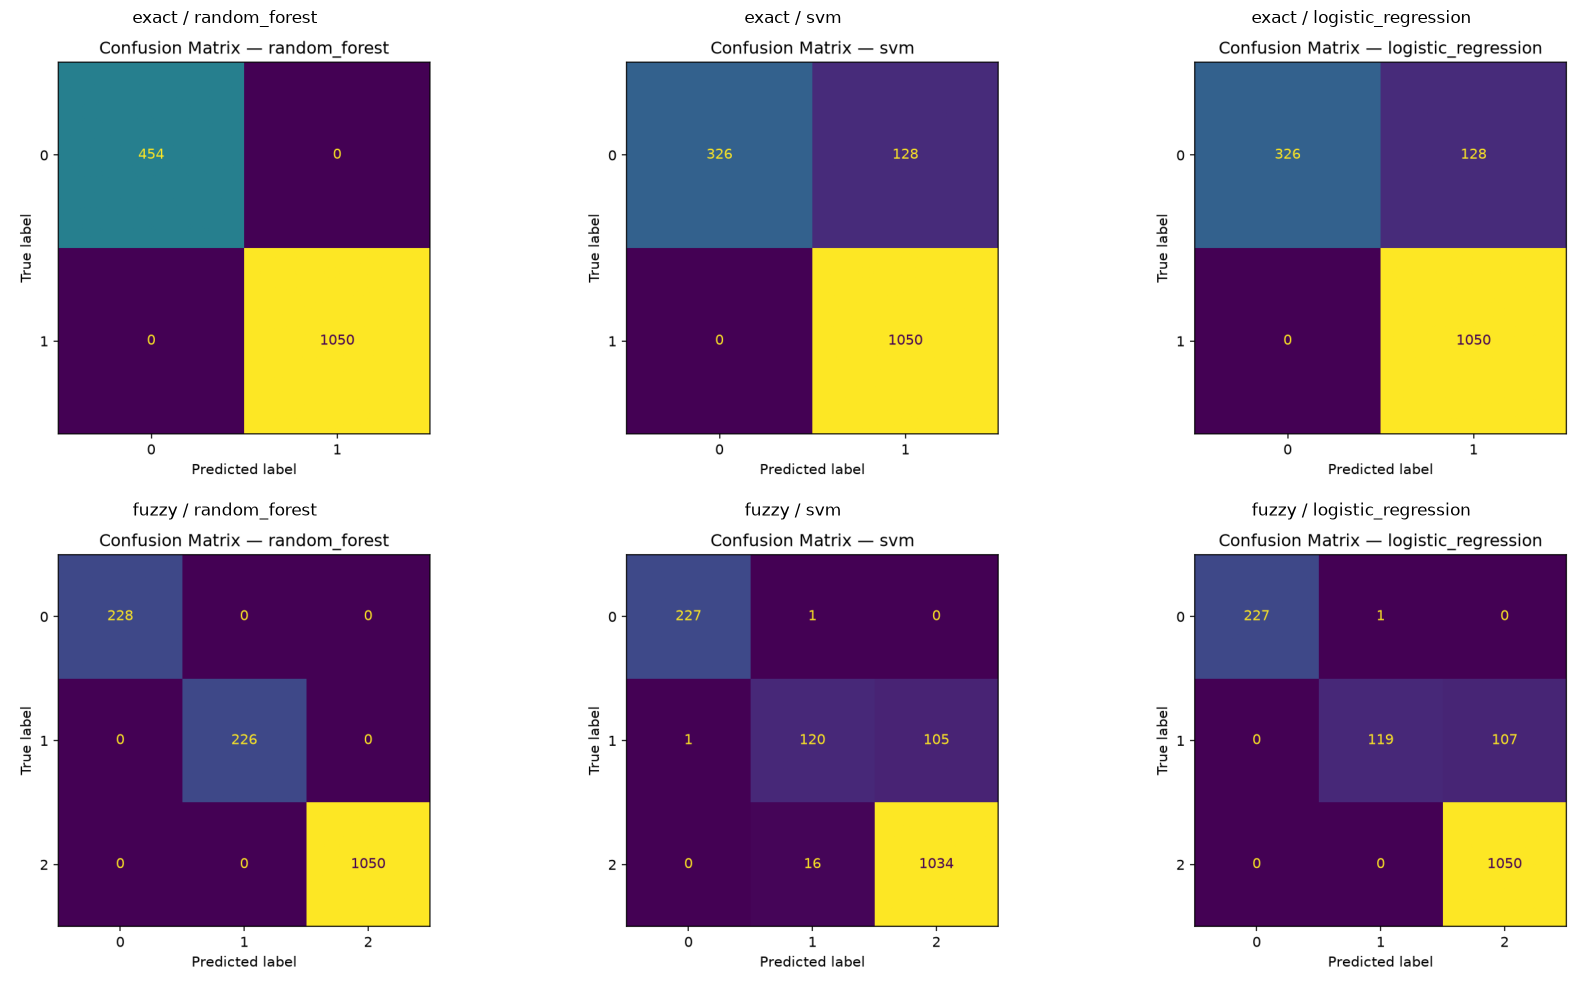

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
algorithms = ["random_forest", "svm", "logistic_regression"]
for row_idx, scenario in enumerate(["exact", "fuzzy"]):
    for col_idx, alg in enumerate(algorithms):
        img_path = Path(f"../data/results/{scenario}/confusion_matrix_{alg}.png")
        if img_path.exists():
            axes[row_idx][col_idx].imshow(mpimg.imread(str(img_path)))
            axes[row_idx][col_idx].axis("off")
            axes[row_idx][col_idx].set_title(f"{scenario} / {alg}")
plt.tight_layout()
plt.show()